# 07 – Model comparison: NYC Citi Bike

**Worked on by:** Andreas Schellekens (paired block bootstrap, practical comparison, choice of the deployed model, error analysis)

> **GenAI disclosure:** the first version of this notebook was drafted with the help of Claude Code (AI assistant), based on `03_model_baseline.ipynb` to `05c_model_ensemble.ipynb`. All steps were reviewed by the team; we must be able to explain every cell ourselves.

## 1. Goal and setup

Every model notebook (03-05c) stored its validation and test metrics in `models/metrics.csv`. This notebook compares the models **properly** and chooses the model for the deployment:

1. a summary of all metrics (section 2);
2. are the differences on the validation year real, or noise? A **paired block bootstrap** (section 3);
3. practical criteria: size, speed, what the API needs (section 4);
4. the choice, made on the validation year with a rule written down **before** looking at the bootstrap (section 5);
5. the test results of all models, reported once more, and an error analysis of the chosen model (sections 6-7).

The AWS model (`06`) is not built yet; it will be added to this comparison when it is. Setup: the chart style, the dataset description and the `evaluate` helper of the protocol.

In [1]:
import os
os.environ.setdefault("LOKY_MAX_CPU_COUNT", "4")

import json
import time
from pathlib import Path

import joblib
import lightgbm  # noqa: F401  (before pycaret, see CLAUDE.md)
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 200)

INK_PRIMARY, INK_SECONDARY, INK_MUTED = "#0b0b0b", "#52514e", "#898781"
STYLE = {
    "figure.facecolor": "white", "axes.facecolor": "white", "axes.edgecolor": "#c3c2b7",
    "axes.grid": True, "grid.color": "#e1e0d9", "grid.linewidth": 0.6,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.labelcolor": INK_SECONDARY, "xtick.color": INK_MUTED, "ytick.color": INK_MUTED,
    "text.color": INK_PRIMARY, "axes.titlesize": 12, "axes.titleweight": "bold",
}
plt.rcParams.update(STYLE)
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"

RANDOM_STATE = 42
MODEL_DIR = Path("models")
with open(MODEL_DIR / "citibike_daily_dataset.json", encoding="utf-8") as file:
    DATASET = json.load(file)


def load(split):
    return pd.read_csv(DATASET["files"][split], index_col="date", parse_dates=["date"])


validation, test = load("validation"), load("test")
metrics = pd.read_csv(MODEL_DIR / "metrics.csv")
print(f"metrics.csv: {len(metrics)} rows from {metrics.notebook.nunique()} notebooks")

metrics.csv: 12 rows from 5 notebooks


## 2. All models at a glance

The metrics of every model on the validation year (used for choices) and the test period (reported only), as stored by the model notebooks. The columns are those of the protocol (03 section 3): MAE and RMSE in trips per day, MAPE and median percentage error, the share of days within 20%, and the bias (above 0 = too many trips predicted).

In [2]:
order = ["seasonal naive", "linear regression (baseline)", "PyCaret blend gbr + rf + lightgbm",
         "gradient boosting (05a)", "Huber regression (05b)", "ensemble 05a + 05b (05c)"]
overview = metrics.set_index(["split", "model"]).drop(columns=["notebook", "days"])
overview = overview.reindex(pd.MultiIndex.from_product([["validation", "test"], order]))
overview.round(1)

mae     rmse  mape  median_ape  within_20pct  bias_pct
validation seasonal naive                     17755.7  24079.1  22.2        10.9          71.9       5.2
           linear regression (baseline)       12787.6  16670.3  12.4         9.7          82.2      -4.2
           PyCaret blend gbr + rf + lightgbm   9657.7  12700.3   9.5         6.3          88.5      -3.1
           gradient boosting (05a)             9499.5  12207.3   9.6         6.4          86.1      -3.1
           Huber regression (05b)             11645.3  15293.6  10.8         8.7          88.3      -2.7
           ensemble 05a + 05b (05c)            9712.1  12667.1   9.3         6.8          90.2      -3.1
test       seasonal naive                     24128.1  32296.4  38.0        14.7          61.9      31.6
           linear regression (baseline)       17205.6  22336.1  17.4        11.9          73.6       7.8
           PyCaret blend gbr + rf + lightgbm  13806.2  17529.1  14.6         9.8          80.9       8.6
           gradient boosting (05a)            14577.8  18235.1  15.1        10.4          80.0       8.8
           Huber regression (05b)             15837.4  20535.3  15.7        11.2          77.9       9.4
           ensemble 05a + 05b (05c)           14363.4  18112.8  14.4        10.2          81.4       8.8

**Interpretation**

- **Validation 2024:** the ensemble (05c) has the lowest MAPE (9.3%) and the most days within 20% (90.2%); gradient boosting (05a) has the lowest MAE (9,500 trips) and RMSE; the PyCaret blend is in between (9.5%). Huber (10.8%) and the baseline (12.4%) follow, the seasonal naive model without weather is far behind (22.2%).
- **Test 2025-2026:** the same top three, now with the ensemble lowest in MAPE (14.4%) and the PyCaret blend lowest in MAE (13,806). Every model is 4-6 points worse than on validation, and every model with weather has a bias of +7.8% to +9.4%: the drift with the growth of the system (03-05c).
- The top three are close, and they are first on different metrics. Section 3 checks whether these differences mean anything.

## 3. Are the differences real? A paired block bootstrap

The validation year has 366 days, so every metric has uncertainty. We compare the models **paired** (on the same days: a hard day is hard for every model) and with a **bootstrap**: draw the days again with replacement, many times, and see how much the difference between two models varies.

One adjustment for time series: neighbouring days are not independent (a cold week is cold for all its days, and the drift lasts months). Resampling single days would pretend we have 366 independent observations and make the intervals too narrow. We therefore resample **whole weeks** (a block bootstrap): 53 weeks, 2,000 resamples. The predictions of every model on the validation year are made here with the saved models (the PyCaret model needs PyCaret and its 32 MB file, which is regenerated by `04` if it is missing; importing PyCaret changes the chart style, so the cell restores ours).

In [3]:
def from_json(name):
    with open(MODEL_DIR / f"{name}.json", encoding="utf-8") as file:
        return json.load(file)["input_columns"]


SAVED = {
    "linear regression (baseline)": "citibike_baseline",
    "gradient boosting (05a)": "citibike_gradient_boosting",
    "Huber regression (05b)": "citibike_huber",
    "ensemble 05a + 05b (05c)": "citibike_ensemble",
}
MODELS = {label: (joblib.load(MODEL_DIR / f"{name}.joblib"), from_json(name)) for label, name in SAVED.items()}


def predict_trips(model, columns, days):
    return pd.Series(np.exp(model.predict(days[columns])) * days.level_12m, index=days.index)


validation_predictions = pd.DataFrame({label: predict_trips(model, columns, validation)
                                       for label, (model, columns) in MODELS.items()})

pycaret_file = MODEL_DIR / "citibike_pycaret.pkl"
if pycaret_file.exists():
    from pycaret.regression import load_model, predict_model
    pycaret_model = load_model(str(pycaret_file.with_suffix("")), verbose=False)
    plt.rcdefaults()  # importing PyCaret changes the matplotlib style; restore ours
    plt.rcParams.update(STYLE)
    PYCARET_COLUMNS = ["weekday", "month", "holiday", "christmas_week", "tmax_c", "precipitation", "snow_on_ground",
                       "day_of_year", "precipitation_mm", "snow_depth_mm", "snowfall_mm", "tmin_c", "wind_ms"]
    frame = validation[PYCARET_COLUMNS].assign(tmax_c_sq=validation.tmax_c ** 2)
    validation_predictions["PyCaret blend gbr + rf + lightgbm"] = (
        np.exp(predict_model(pycaret_model, data=frame, verbose=False).prediction_label.to_numpy()) * validation.level_12m)
else:
    print("citibike_pycaret.pkl not found (run 04 first); the PyCaret model is left out of the bootstrap")

# the predictions must reproduce the stored validation metrics
for label in validation_predictions:
    stored = metrics[(metrics.model == label) & (metrics.split == "validation")].mae.iloc[0]
    assert np.isclose((validation_predictions[label] - validation.total).abs().mean(), stored), label
print("validation predictions reproduce metrics.csv for:", list(validation_predictions))

validation predictions reproduce metrics.csv for: ['linear regression (baseline)', 'gradient boosting (05a)', 'Huber regression (05b)', 'ensemble 05a + 05b (05c)', 'PyCaret blend gbr + rf + lightgbm']


For every resample we compute each model's MAPE and MAE, and the difference with the reference model, the **ensemble (05c)**, which has the lowest validation MAPE. A difference above 0 means the other model is worse than the ensemble. The 95% interval is the 2.5th to 97.5th percentile of the 2,000 differences; if it contains 0, the validation year cannot tell the two models apart.

In [4]:
REFERENCE = "ensemble 05a + 05b (05c)"
days = validation[validation.total > 0]
percentage_error = validation_predictions.loc[days.index].sub(days.total, axis=0).abs().div(days.total, axis=0) * 100
absolute_error = validation_predictions.loc[days.index].sub(days.total, axis=0).abs()
week = days.index.to_period("W")
weeks = week.unique()
positions_per_week = {w: np.flatnonzero(week == w) for w in weeks}

rng = np.random.default_rng(RANDOM_STATE)
mape_differences, mae_differences = [], []
for _ in range(2000):
    drawn = rng.choice(len(weeks), size=len(weeks), replace=True)
    positions = np.concatenate([positions_per_week[weeks[i]] for i in drawn])
    mape = percentage_error.iloc[positions].mean()
    mae = absolute_error.iloc[positions].mean()
    mape_differences.append(mape - mape[REFERENCE])
    mae_differences.append(mae - mae[REFERENCE])
mape_differences, mae_differences = pd.DataFrame(mape_differences), pd.DataFrame(mae_differences)

bootstrap = pd.DataFrame({
    "MAPE": percentage_error.mean(),
    "MAPE difference": mape_differences.mean(),
    "MAPE 95% low": mape_differences.quantile(0.025), "MAPE 95% high": mape_differences.quantile(0.975),
    "MAE": absolute_error.mean(),
    "MAE difference": mae_differences.mean(),
    "MAE 95% low": mae_differences.quantile(0.025), "MAE 95% high": mae_differences.quantile(0.975),
}).sort_values("MAPE")
bootstrap["MAPE clearly worse"] = bootstrap["MAPE 95% low"] > 0
bootstrap.round(2)

,MAPE,MAPE difference,MAPE 95% low,MAPE 95% high,MAE,MAE difference,MAE 95% low,MAE 95% high,MAPE clearly worse
ensemble 05a + 05b (05c),9.27,0.00,0.00,0.00,9712.10,0.00,0.00,0.00,False
PyCaret blend gbr + rf + lightgbm,9.53,0.26,-0.52,1.06,9657.65,-68.00,-759.18,635.74,False
gradient boosting (05a),9.64,0.36,-0.39,1.12,9499.55,-230.37,-888.31,403.81,False
Huber regression (05b),10.81,1.55,0.96,2.16,11645.33,1946.67,1286.76,2683.38,True
linear regression (baseline),12.36,3.09,2.03,4.37,12787.58,3086.10,2232.65,3976.28,True


**Interpretation**

- **The top three cannot be told apart on the validation year.** Gradient boosting is 0.36 points worse in MAPE than the ensemble, but the 95% interval runs from -0.39 to 1.12: it includes 0. The same holds for the PyCaret blend (+0.26, -0.52 to 1.06). In trips, gradient boosting is even 230 trips per day better than the ensemble, with an interval (-888 to +404) that also includes 0.
- **Huber and the baseline are clearly worse:** +1.55 points (0.96 to 2.16) and +3.09 points (2.03 to 4.37). Their intervals lie entirely above 0.
- So the validation year separates the models into two groups: the three tree-based models (alone or combined) at about 9.3-9.6%, and the linear models behind them. Within the top group, which model "wins" depends on the metric and on chance.

The same intervals as a chart (MAPE difference with the ensemble; the bar is the 95% interval):

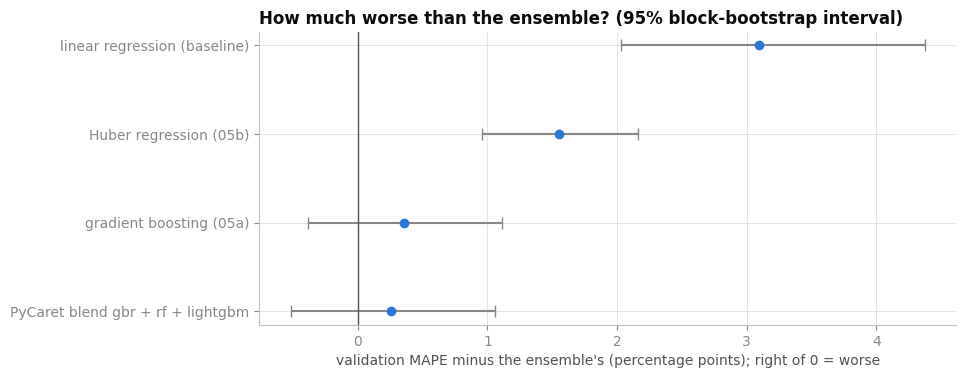

In [5]:
others = bootstrap.drop(index=REFERENCE).sort_values("MAPE difference")
fig, ax = plt.subplots(figsize=(9, 3.8))
y = np.arange(len(others))
ax.errorbar(others["MAPE difference"], y, xerr=[others["MAPE difference"] - others["MAPE 95% low"],
                                                others["MAPE 95% high"] - others["MAPE difference"]],
            fmt="o", color=BLUE, ecolor=INK_MUTED, capsize=4)
ax.axvline(0, color=INK_SECONDARY, linewidth=1)
ax.set_yticks(y, others.index)
ax.set_xlabel("validation MAPE minus the ensemble's (percentage points); right of 0 = worse")
ax.set_title("How much worse than the ensemble? (95% block-bootstrap interval)", loc="left")
plt.show()

## 4. Practical criteria

Accuracy is not the only thing that matters for a deployed model. For every candidate: the file size, the time for one prediction (one day, as the API will ask), what the API must install, and whether a person can explain a prediction.

In [6]:
one_day = validation.iloc[[100]]
rows = []
for label, name in SAVED.items():
    model, columns = MODELS[label]
    start = time.perf_counter()
    for _ in range(200):
        model.predict(one_day[columns])
    milliseconds = (time.perf_counter() - start) / 200 * 1000
    rows.append({"model": label, "file (KB)": (MODEL_DIR / f"{name}.joblib").stat().st_size / 1024,
                 "ms per prediction": milliseconds, "inputs": len(columns), "API needs": "scikit-learn"})
if pycaret_file.exists():
    frame = one_day[PYCARET_COLUMNS].assign(tmax_c_sq=one_day.tmax_c ** 2)
    start = time.perf_counter()
    for _ in range(20):
        predict_model(pycaret_model, data=frame, verbose=False)
    rows.append({"model": "PyCaret blend gbr + rf + lightgbm", "file (KB)": pycaret_file.stat().st_size / 1024,
                 "ms per prediction": (time.perf_counter() - start) / 20 * 1000, "inputs": len(PYCARET_COLUMNS),
                 "API needs": "PyCaret, LightGBM"})
practical = pd.DataFrame(rows).set_index("model")
practical["explainable"] = ["coefficients", "permutation importance", "coefficients", "both members",
                            "importance only"][:len(practical)]
practical.round(1)

,file (KB),ms per prediction,inputs,API needs,explainable
model,,,,,
linear regression (baseline),4.5,3.8,7,scikit-learn,coefficients
gradient boosting (05a),551.6,7.8,11,scikit-learn,permutation importance
Huber regression (05b),3.2,5.1,16,scikit-learn,coefficients
ensemble 05a + 05b (05c),557.3,14.0,17,scikit-learn,both members
PyCaret blend gbr + rf + lightgbm,31282.9,102.1,13,"PyCaret, LightGBM",importance only


**Interpretation**

- The **PyCaret blend** is out of the race for the deployment: a 31 MB file, about 107 ms per prediction (20 times slower than the others) and the API would need PyCaret and LightGBM, including the LightGBM workaround on Windows.
- The four scikit-learn models all predict in a few milliseconds (measured on this laptop, one day at a time), far below anything a user would notice. **Gradient boosting** is one model of 552 KB; the **ensemble** contains it plus the 3 KB Huber pipeline, so it is barely larger (557 KB) but needs both members (twice the prediction time, 9.2 ms) and 17 inputs instead of 11.
- Both linear models can be explained coefficient by coefficient; gradient boosting only through importances; the ensemble half and half.

## 5. The choice

The rule, written down before the bootstrap was run (as the protocol of 03 says: models are chosen on the validation year):

1. Only models that the API can run with scikit-learn alone are candidates (the PyCaret blend needs PyCaret, a 32 MB file and LightGBM's Windows workaround).
2. The candidate with the **lowest validation MAPE** wins (the protocol's main metric).
3. Unless a smaller or simpler candidate is **not clearly worse** (its 95% interval of the MAPE difference contains 0); then the simpler one is preferred.

In [7]:
candidates = bootstrap.drop(index=["PyCaret blend gbr + rf + lightgbm"], errors="ignore")
best = candidates["MAPE"].idxmin()
simpler = {"ensemble 05a + 05b (05c)": ["gradient boosting (05a)", "Huber regression (05b)", "linear regression (baseline)"],
           "gradient boosting (05a)": ["Huber regression (05b)", "linear regression (baseline)"],
           "Huber regression (05b)": ["linear regression (baseline)"], "linear regression (baseline)": []}
not_clearly_worse = [name for name in simpler[best] if not candidates.loc[name, "MAPE clearly worse"]]
DEPLOYED = not_clearly_worse[-1] if not_clearly_worse else best  # the simplest one that is not clearly worse
print(f"lowest validation MAPE: {best}")
print(f"simpler candidates that are not clearly worse: {not_clearly_worse or 'none'}")
print(f"deployed model: {DEPLOYED}")

lowest validation MAPE: ensemble 05a + 05b (05c)
simpler candidates that are not clearly worse: ['gradient boosting (05a)']
deployed model: gradient boosting (05a)


**Interpretation:** the ensemble has the lowest validation MAPE, but gradient boosting is **not clearly worse** (section 3) and it is the simpler model: one model instead of two, half the prediction time and six inputs fewer. Following the rule, **the deployed model is the gradient boosting model of 05a** (`models/citibike_gradient_boosting.joblib`). The same reasoning chose gradient boosting for the mushrooms (`SecondaryMushroom/07`).

This is a choice between near-equals, and section 7 shows the one place where the ensemble is clearly better: the big holidays. Because both models take the same kind of input and return the same output (the log ratio), switching later is a matter of replacing one file and its JSON.

## 6. The test period, for all models

The test numbers were each computed once, in the model notebooks, after all choices. They are shown here together, with the same block bootstrap, to see whether the order of the validation year holds on unseen data. Nothing is chosen on these numbers.

In [8]:
test_predictions = pd.DataFrame({label: predict_trips(model, columns, test) for label, (model, columns) in MODELS.items()})
test_days = test[test.total > 0]
test_error = test_predictions.loc[test_days.index].sub(test_days.total, axis=0).abs().div(test_days.total, axis=0) * 100
test_weeks = test_days.index.to_period("W")
unique_weeks = test_weeks.unique()
week_positions = {w: np.flatnonzero(test_weeks == w) for w in unique_weeks}
differences = []
for _ in range(2000):
    drawn = rng.choice(len(unique_weeks), size=len(unique_weeks), replace=True)
    mape = test_error.iloc[np.concatenate([week_positions[unique_weeks[i]] for i in drawn])].mean()
    differences.append(mape - mape[DEPLOYED])
differences = pd.DataFrame(differences)
pd.DataFrame({"test MAPE": test_error.mean(), "difference with the deployed model": differences.mean(),
              "95% low": differences.quantile(0.025), "95% high": differences.quantile(0.975),
              "test bias": (test_predictions.loc[test_days.index].sub(test_days.total, axis=0)
                            .div(test_days.total, axis=0) * 100).mean()}).sort_values("test MAPE").round(2)

,test MAPE,difference with the deployed model,95% low,95% high,test bias
ensemble 05a + 05b (05c),14.39,-0.69,-1.50,0.06,8.78
gradient boosting (05a),15.08,0.00,0.00,0.00,8.77
Huber regression (05b),15.72,0.63,-0.80,1.92,9.36
linear regression (baseline),17.39,2.30,0.78,3.87,7.77


**Interpretation**

- **The order of the validation year holds on the test period:** ensemble 14.39%, gradient boosting 15.08%, Huber 15.72%, baseline 17.39%. The ensemble is 0.69 points better than the deployed model, with an interval of -1.50 to 0.06: almost, but not quite, a clear difference. The baseline is clearly worse (+2.30, 0.78 to 3.87); Huber is not clearly different (+0.63, -0.80 to 1.92).
- The test period does not change the choice (the protocol does not allow it), but it is consistent with what section 3 found: the ensemble is at most a little better than gradient boosting alone.
- All models have about the same bias (+7.8% to +9.4%): the drift is shared, not a property of one model.

## 7. Where does the deployed model go wrong?

The error of the deployed model on the validation year and the test period, split by the conditions that matter for demand: the precipitation class, the temperature, the weekday and the type of day. The percentage errors are on days with trips; the bias shows whether the model predicts too many (above 0) or too few trips.

In [9]:
model, columns = MODELS[DEPLOYED]
analysis = pd.concat([validation.assign(set="validation"), test.assign(set="test")])
analysis = analysis[analysis.total > 0].copy()
analysis["predicted"] = predict_trips(model, columns, analysis)
analysis["error_pct"] = (analysis.predicted - analysis.total) / analysis.total * 100
analysis["temperature"] = pd.cut(analysis.tmax_c, [-30, 5, 15, 25, 45], labels=["below 5", "5-15", "15-25", "above 25"])
analysis["day type"] = np.select(
    [analysis[["thanksgiving", "day_after_thanksgiving", "christmas_day", "new_years_day"]].sum(axis=1) > 0,
     analysis.holiday == 1, analysis.christmas_week == 1, analysis.weekday >= 5],
    ["big holiday", "other federal holiday", "Christmas week", "weekend"], "working day")


def summarise(by):
    grouped = analysis.groupby(["set", by], observed=True).error_pct
    return pd.DataFrame({"days": grouped.size(), "MAPE": grouped.apply(lambda e: e.abs().mean()),
                         "bias": grouped.mean()}).unstack("set").round(1)


for by in ["precipitation", "temperature", "day type"]:
    print(f"\nby {by}:")
    print(summarise(by).to_string())


by precipitation:
              days             MAPE             bias           
set           test validation  test validation  test validation
precipitation                                                  
dry            392        241  12.5        7.4   9.5       -1.5
heavy           38         21  18.5       19.8  -2.9       -2.8
light           92         51  20.5       10.9  13.6       -4.0
moderate        67         42  15.8       13.4   4.5       -7.3
very heavy      17         11  33.8       19.7   8.9      -17.8

by temperature:
            days             MAPE             bias           
set         test validation  test validation  test validation
temperature                                                  
below 5      105         41  26.4       16.1  17.2       -3.9
5-15         152        101  15.3       12.6   5.4       -5.3
15-25        152        111  13.0        8.0   7.5       -2.0
above 25     197        113  10.5        6.3   7.9       -1.9

by day type:
    

**Interpretation** (deployed model, gradient boosting)

- **Rain:** dry days are predicted best (MAPE 7.4% on validation, 12.5% on test), very heavy rain worst (19.7% and 33.8%, on only 11 and 17 days). On validation the model predicts too few trips on very heavy rain days (bias -17.8%): when a storm falls in a few hours, the daily total overstates its effect (03, 05a).
- **Temperature:** the colder the day, the larger the error. Below 5 degrees the test MAPE is 26.4% with a bias of +17.2%: the cold, snowy weeks of January and February 2026. Above 25 degrees the error is smallest (6.3% and 10.5%).
- **Type of day:** the big holidays are the worst (MAPE 34-36%, the model predicts about a third too many trips), followed by the rest of the Christmas week (test +44.6%). Gradient boosting cannot use the big-holiday flags (05a section 2). On ordinary working days the test bias of +10.1% is the drift; weekends are less affected (+4.0%).

Would the ensemble, the model with the lowest validation MAPE, do better on these days? The same split by type of day, for both models, on the validation year and the test period together:

In [10]:
ensemble_model, ensemble_columns = MODELS[REFERENCE]
analysis["ensemble_error_pct"] = (predict_trips(ensemble_model, ensemble_columns, analysis) - analysis.total) / analysis.total * 100
by_day = analysis.groupby("day type").agg(days=("error_pct", "size"),
                                          deployed_MAPE=("error_pct", lambda e: e.abs().mean()),
                                          ensemble_MAPE=("ensemble_error_pct", lambda e: e.abs().mean()),
                                          deployed_bias=("error_pct", "mean"), ensemble_bias=("ensemble_error_pct", "mean"))
by_day.round(1)

,days,deployed_MAPE,ensemble_MAPE,deployed_bias,ensemble_bias
day type,,,,,
Christmas week,14,36.4,32.2,29.8,24.6
big holiday,9,34.9,24.2,33.6,22.4
other federal holiday,21,15.2,12.3,-1.8,-2.0
weekend,274,13.8,12.8,-0.6,-1.0
working day,654,11.8,11.7,5.6,6.0


**Interpretation:** on ordinary working days the two models are equal (11.8% against 11.7%). On every kind of special day the ensemble is better: big holidays 24.2% against 34.9% (bias +22% against +34%), the Christmas week 32.2% against 36.4%, other federal holidays 12.3% against 15.2%, weekends 12.8% against 13.8%. That is the Huber member's holiday flags at work (05b). There are few such days (9 big holidays and 14 other Christmas-week days in 2024-2026), so they hardly move the overall MAPE, but they are exactly the days on which a user of the app would notice a bad prediction. **This is the strongest argument for switching the deployment to the ensemble**; we leave that decision to the team, because the rule of section 5, fixed in advance, chose gradient boosting.

The chart puts the two halves of the error side by side: the error per day of the test period (grey) and its 30-day moving average (blue), which shows the drift.

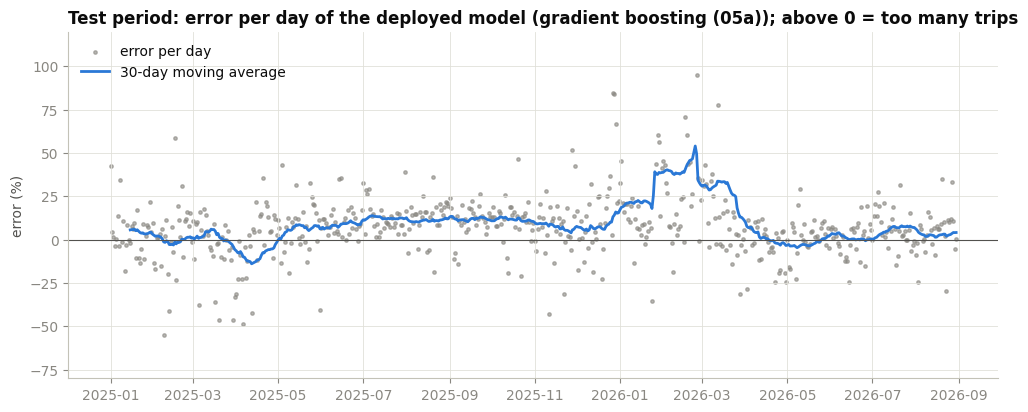

days outside the plotted range: 3


In [11]:
test_part = analysis[analysis.set == "test"]
fig, ax = plt.subplots(figsize=(12, 4.5))
ax.scatter(test_part.index, test_part.error_pct, s=6, color=INK_MUTED, alpha=0.6, label="error per day")
ax.plot(test_part.index, test_part.error_pct.rolling(30, min_periods=15).mean(), color=BLUE, linewidth=2,
        label="30-day moving average")
ax.axhline(0, color=INK_SECONDARY, linewidth=0.8)
ax.set_ylim(-80, 120)
ax.set_ylabel("error (%)")
ax.set_title(f"Test period: error per day of the deployed model ({DEPLOYED}); above 0 = too many trips", loc="left")
ax.legend(loc="upper left", frameon=False)
plt.show()
print(f"days outside the plotted range: {((test_part.error_pct < -80) | (test_part.error_pct > 120)).sum()}")

**Interpretation:** the error has two parts. The **daily scatter** (grey) is mostly within about +-25%: the weather of a single day that the daily totals cannot fully describe (rain timing, a holiday the model does not know). The **drift** (blue) moves slowly: about 0 in early 2025 (slightly negative in March-April), +10% to +15% from June to December 2025 when growth stopped, a peak of +35% to +55% in the snowy weeks of late January and February 2026, and back to about 0 from April 2026. Three days fall outside the plotted range: the blizzard of 25-26 January 2026 (290 mm of snow) and 24 February 2026, the day after the storm that closed the system, with 356 mm of snow on the ground. The model predicted two to six times the actual trips on those days.

The drift is the larger and more systematic part, and no model in this project removed it (05a: growth feature; 05c: recent-error correction). In the deployment, **retraining with the newest months** is the natural remedy: the level and the ratios then include the period in which growth stopped.

## 8. Conclusion

- **Ranking (validation 2024, MAPE):** ensemble 9.3%, PyCaret blend 9.5%, gradient boosting 9.6% (these three cannot be told apart), Huber 10.8%, baseline 12.4%, seasonal naive 22.2%. The test period gives the same order (14.4%, 14.6%, 15.1%, 15.7%, 17.4%, 38.0%).
- **Deployed model: gradient boosting (05a)**, `models/citibike_gradient_boosting.joblib` with its JSON. Chosen by a rule fixed in advance: the lowest validation MAPE, unless a simpler model is not clearly worse. It needs only scikit-learn, takes 552 KB and about 5 ms per prediction.
- **What the API needs:** the date (weekday, month, day of the year, holidays), a weather forecast for that day (maximum and minimum temperature, precipitation, snowfall and snow depth in mm, wind; wind may be missing), and the level `level_12m` from `Data/citibike_monthly.csv`. The prediction in trips is `exp(model output) x level_12m` (03 section 8 shows the recipe).
- **What to expect:** a typical error of about 10% on the validation year and 15% on the test period. In practice the weather will be a **forecast**, not a measurement, so the errors will be somewhat larger.
- **Known weaknesses:** the drift when the growth of the system changes (test bias +8.8%), the big holidays (about a third too high; the ensemble halves that), very heavy rain and cold, snowy weeks.
- **Open decisions for the team:** switching the deployment to the ensemble (better on holidays, same size class); adding the AWS model (`06`) to this comparison when it is built.